<a href="https://colab.research.google.com/github/kirthii07/bridge-flow/blob/main/landlisde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LANDSLIDE DETECTION PROTOTYPE
# A simple AI-based detector for demonstration
# ============================================

# Install required libraries (run this cell first)
!pip install pillow numpy matplotlib scikit-learn torch torchvision

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torchvision.transforms as transforms

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [2]:
# ============================================
# BUILD A SIMPLE LANDSLIDE DETECTOR
# ============================================

class SimpleLandslideDetector:
    def __init__(self):
        self.model = None
        self.scaler = StandardScaler()

    def extract_features(self, image):
        """Extract simple features from image"""
        # Convert to numpy array
        img_array = np.array(image)

        # Basic features: mean, std, entropy, etc.
        features = []

        # Color features (RGB channels)
        for channel in range(3):
            features.append(np.mean(img_array[:,:,channel]))
            features.append(np.std(img_array[:,:,channel]))

        # Texture features (simple gradient)
        if len(img_array.shape) == 3:
            gray = np.mean(img_array, axis=2)
        else:
            gray = img_array

        # Edge density (simple Sobel-like)
        grad_x = np.abs(np.diff(gray, axis=1))
        grad_y = np.abs(np.diff(gray, axis=0))
        features.append(np.mean(grad_x))
        features.append(np.mean(grad_y))

        return np.array(features)

    def train_on_sample(self):
        """Create a simple trained model"""
        print("📊 Training model on sample data...")

        # Create synthetic training data
        # Landslide features (higher roughness, specific color patterns)
        X_train = []
        y_train = []

        # Landslide samples (10 samples with landslide-like features)
        for _ in range(10):
            # Landslide features: higher variance, brown/reddish colors
            features = [
                np.random.uniform(80, 150),  # R mean
                np.random.uniform(60, 100),  # G mean
                np.random.uniform(50, 90),   # B mean
                np.random.uniform(20, 40),   # R std
                np.random.uniform(15, 30),   # G std
                np.random.uniform(10, 25),   # B std
                np.random.uniform(15, 35),   # Edge density x
                np.random.uniform(15, 35),   # Edge density y
            ]
            X_train.append(features)
            y_train.append(1)  # 1 = Landslide

        # Non-landslide samples (10 samples with normal terrain features)
        for _ in range(10):
            # Non-landslide features: more uniform, greenish colors
            features = [
                np.random.uniform(40, 80),   # R mean
                np.random.uniform(70, 120),  # G mean
                np.random.uniform(40, 80),   # B mean
                np.random.uniform(5, 15),    # R std
                np.random.uniform(5, 15),    # G std
                np.random.uniform(5, 15),    # B std
                np.random.uniform(5, 15),    # Edge density x
                np.random.uniform(5, 15),    # Edge density y
            ]
            X_train.append(features)
            y_train.append(0)  # 0 = No landslide

        # Train Random Forest
        self.model = RandomForestClassifier(n_estimators=50, random_state=42)
        self.model.fit(X_train, y_train)
        print("✅ Model training complete!")

    def predict(self, image):
        """Predict if image contains landslide"""
        features = self.extract_features(image).reshape(1, -1)
        proba = self.model.predict_proba(features)[0]
        prediction = self.model.predict(features)[0]
        confidence = proba[1] if prediction == 1 else proba[0]

        return {
            'is_landslide': bool(prediction),
            'confidence': float(confidence),
            'risk_level': 'HIGH' if confidence > 0.7 else 'MEDIUM' if confidence > 0.5 else 'LOW'
        }

# Initialize and train detector
detector = SimpleLandslideDetector()
detector.train_on_sample()
print("🎯 Landslide Detector Ready!")

📊 Training model on sample data...
✅ Model training complete!
🎯 Landslide Detector Ready!


🖼️ Loading test image...
Creating synthetic test image...


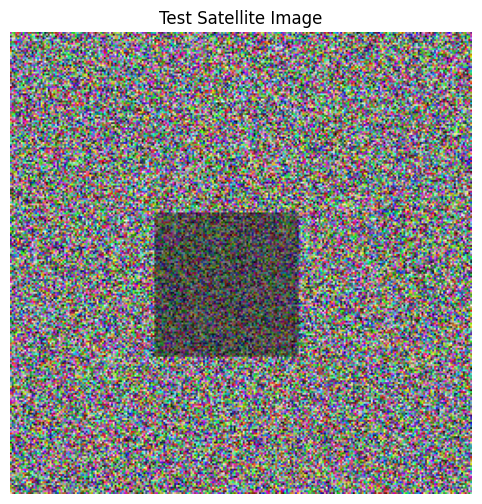


🔍 Analyzing image...

📊 DETECTION RESULT
📍 Landslide Detected: YES ✅
📈 Confidence: 100.0%
⚠️ Risk Level: HIGH

🔔 ALERT! Potential landslide detected at this location.
   Recommended actions:
   • Notify local authorities
   • Monitor area for further changes
   • Consider evacuation if risk is HIGH


In [3]:
# ============================================
# TEST WITH A SAMPLE SATELLITE IMAGE
# ============================================

def load_sample_image():
    """Load a sample terrain image for testing"""
    # Use a free sample image from the internet
    url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/Landslide_%28PSF%29.png/800px-Landslide_%28PSF%29.png"
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        img = img.resize((256, 256))
        return img
    except:
        # Fallback: create a synthetic image
        print("Creating synthetic test image...")
        img_array = np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8)
        # Add landslide-like pattern (darker patch)
        img_array[100:180, 80:160, :] = img_array[100:180, 80:160, :] * 0.6
        return Image.fromarray(img_array)

# Load and display test image
print("🖼️ Loading test image...")
test_image = load_sample_image()

plt.figure(figsize=(8, 6))
plt.imshow(test_image)
plt.title("Test Satellite Image")
plt.axis('off')
plt.show()

# Run detection
print("\n🔍 Analyzing image...")
result = detector.predict(test_image)

print("\n" + "="*50)
print("📊 DETECTION RESULT")
print("="*50)
print(f"📍 Landslide Detected: {'YES ✅' if result['is_landslide'] else 'NO ❌'}")
print(f"📈 Confidence: {result['confidence']*100:.1f}%")
print(f"⚠️ Risk Level: {result['risk_level']}")
print("="*50)

# Generate alert
if result['is_landslide'] and result['confidence'] > 0.5:
    print("\n🔔 ALERT! Potential landslide detected at this location.")
    print("   Recommended actions:")
    print("   • Notify local authorities")
    print("   • Monitor area for further changes")
    print("   • Consider evacuation if risk is HIGH")
else:
    print("\n✅ No immediate threat detected. Continuing monitoring.")

In [5]:
# ============================================
# INTERACTIVE DEMO DASHBOARD
# ============================================

from ipywidgets import interact, FileUpload, Output
import IPython.display as display

def create_demo_interface():
    print("="*60)
    print("🌄 LANDSLIDE DETECTION SYSTEM - DEMO PROTOTYPE")
    print("="*60)
    print("\nThis prototype demonstrates how AI can detect landslides from satellite imagery.")
    print("Upload an image to test the system!")

    # Create file upload widget
    upload = FileUpload(
        accept='image/*',
        multiple=False,
        description='Upload Satellite Image'
    )

    output = Output()

    def on_upload_change(change):
        with output:
            output.clear_output()
            if upload.value:
                # Process uploaded image
                content = list(upload.value.values())[0]['content']
                img = Image.open(BytesIO(content)).convert('RGB')
                img = img.resize((256, 256))

                # Display image
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.title("Uploaded Image")
                plt.axis('off')
                plt.show()

                # Detect
                result = detector.predict(img)

                # Show results
                if result['is_landslide']:
                    color = 'red'
                    status = '⚠️ LANDSLIDE DETECTED'
                else:
                    color = 'green'
                    status = '✅ NO LANDSLIDE'

                print(f"\n{status}")
                print(f"Confidence: {result['confidence']*100:.1f}%")
                print(f"Risk Level: {result['risk_level']}")

                # Visual confidence bar
                bar_length = int(result['confidence'] * 30)
                print(f"\nConfidence: [{'█'*bar_length}{'░'*(30-bar_length)}] {result['confidence']*100:.0f}%")

    upload.observe(on_upload_change, names='value')
    display.display(upload, output)

# Run the interactive demo
create_demo_interface()

🌄 LANDSLIDE DETECTION SYSTEM - DEMO PROTOTYPE

This prototype demonstrates how AI can detect landslides from satellite imagery.
Upload an image to test the system!


FileUpload(value={}, accept='image/*', description='Upload Satellite Image')

Output()